## Task Overview

In this lab you will build a **Convolutional Neural Network (CNN)** and use it to
classify images from the
[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset.

**After completing this task, you will know how to:**

- Load and augment a color-image dataset (CIFAR-10) in PyTorch
- Build a CNN with convolutional, batch-normalization, and pooling layers
- Train the model with a standard PyTorch training loop
- Evaluate accuracy and visualize predictions

**The big idea:** convolutional layers slide small filters over the image to
detect local patterns (edges, textures, shapes). Stacking several conv blocks
lets the network build up from simple features to more complex ones, and a final
fully-connected classifier turns those features into class scores.

## Task

Follow the instructions below to complete your coding assignment.

Run the code in the sections beginning with "Static" unchanged, unless otherwise
indicated. Fill in every cell marked `## Answer here`.

### Static code

In [ ]:
#(optional if you are running this notebook in Colab)
# @title Mount drive and run imports
from google.colab import drive
drive.mount("/content/gdrive")

In [13]:
# @title Importing Necessary Packages

import copy
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torch.utils.data as data
from torch.utils.data import DataLoader
from torchvision.transforms import v2

In [14]:
# @title Device, seed helper, and save path

# Use a GPU if one is available, otherwise fall back to CPU.
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed):
    """Set seed for reproducibility."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # MPS (Apple Silicon)
    # torch.manual_seed() already seeds MPS.
    # No torch.mps.manual_seed_all() exists.
# Modify 'save_dir' to the path where the CIFAR-10 dataset should be downloaded.
save_dir = "./data"

Using device: mps


### Task 1
#### **Load, augment, and prepare CIFAR-10 data (Steps 1-4)**

In this task you will:

1) Define preprocessing pipelines (with augmentation for training, without for
   evaluation).
2) Load CIFAR-10 and split the training data into train and validation sets.
3) Wrap the datasets in `DataLoader`s.
4) Visualize a sample image.

#### Step 1: Define the preprocessing pipelines

Use `v2.Compose` to build two pipelines named `train_transforms` and
`test_transforms`.

- `train_transforms` (with augmentation), in order: `v2.RandomHorizontalFlip()`,
  `v2.RandomCrop(32, padding=4)`, `v2.ToImage()`,
  `v2.ToDtype(torch.float32, scale=True)`, `v2.Normalize(mean, std)`.
- `test_transforms` (no augmentation): `v2.ToImage()`,
  `v2.ToDtype(torch.float32, scale=True)`, `v2.Normalize(mean, std)`.

Use the CIFAR-10 per-channel statistics: `mean = (0.4914, 0.4822, 0.4465)` and
`std = (0.2470, 0.2435, 0.2616)`.

In [15]:
## Answer here

# CIFAR-10 has 3 color channels (RGB), so mean/std each hold three values -- one
# per channel. These constants are precomputed over the CIFAR-10 training set.
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)

# Training pipeline WITH augmentation. The random flip and crop create slightly
# different versions of each image every epoch, which helps the model generalize
# instead of memorizing the training images.
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),               # 50% chance to mirror left-right
    v2.RandomCrop(32, padding=4),            # pad 4px then crop back (random shift)
    v2.ToImage(),                            # PIL image -> tensor
    v2.ToDtype(torch.float32, scale=True),   # 0-255 ints -> 0.0-1.0 floats
    v2.Normalize(mean=cifar_mean, std=cifar_std),  # center each channel
])

# Evaluation pipeline WITHOUT augmentation -- clean images only.
test_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=cifar_mean, std=cifar_std),
])

#### Step 2: Load the data and split into train / validation

Use `datasets.CIFAR10` to create `train_data` (train=True, `train_transforms`)
and `test_data` (train=False, `test_transforms`), with `download=True`.

Then use `data.random_split` with a 90/10 ratio to split `train_data` into
`train_data` and `validate_data`. Finally, `copy.deepcopy` the validation subset
and set its `.dataset.transform` to `test_transforms` so validation images are
**not** augmented.

In [16]:
## Answer here

# Load the full CIFAR-10 training set (50,000 images) with augmenting transforms.
train_data = datasets.CIFAR10(
    root=save_dir, train=True, transform=train_transforms, download=True
)

# Load the CIFAR-10 test set (10,000 images) with clean (non-augmented) transforms.
test_data = datasets.CIFAR10(
    root=save_dir, train=False, transform=test_transforms, download=True
)

# Carve a validation set out of the training data (90% train / 10% validation) so
# we never tune the model on the test set.
train_size = int(0.9 * len(train_data))   # 45,000
val_size = len(train_data) - train_size   # 5,000
train_data, validate_data = data.random_split(train_data, [train_size, val_size])

# The validation subset still points at the augmenting dataset. Deep-copy it so we
# can give it its own transform without affecting the training subset...
validate_data = copy.deepcopy(validate_data)
# ...then swap in the clean transforms for validation.
validate_data.dataset.transform = test_transforms

Files already downloaded and verified
Files already downloaded and verified


Check: After creating the three datasets you should see:

    Train samples: 45000
    Validation samples: 5000
    Test samples: 10000

In [17]:
print("Train samples:", len(train_data))
print("Validation samples:", len(validate_data))
print("Test samples:", len(test_data))

Train samples: 45000
Validation samples: 5000
Test samples: 10000


#### Step 3: Make the DataLoaders

Use `DataLoader` to create `train_loader`, `validate_loader`, and `test_loader`
with `batch_size=50`. Shuffle **only** the `train_loader`. Call `set_seed(1)`
before creating the loaders so results are reproducible.

In [18]:
## Answer here

# Fix the RNG so batch shuffling is reproducible across runs.
set_seed(1)

# Training loader shuffles so the model doesn't learn the order of examples.
train_loader = DataLoader(train_data, batch_size=50, shuffle=True)
# Validation/test loaders keep a fixed order (no need to shuffle for evaluation).
validate_loader = DataLoader(validate_data, batch_size=50, shuffle=False)
test_loader = DataLoader(test_data, batch_size=50, shuffle=False)

#### Step 4: Visualize a sample image

Grab one batch from `train_loader` with `iter`/`next`, pick `idx = 1`, and
display the image with its class name as the title. Because the images are
normalized, **un-normalize** them first (multiply by `std`, add `mean`, then
clamp to `[0, 1]`) and `permute` the tensor from `(C, H, W)` to `(H, W, C)`.

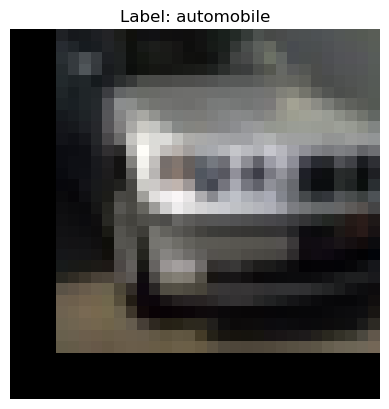

In [19]:
## Answer here

# CIFAR-10 label index -> human-readable class name.
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Get one batch (images shape: (50, 3, 32, 32)).
images, labels = next(iter(train_loader))

idx = 1
img = images[idx]            # (3, 32, 32), still normalized
label = labels[idx].item()

# Undo the normalization so colors look natural: multiply by std, add mean.
mean = torch.tensor(cifar_mean).view(3, 1, 1)
std = torch.tensor(cifar_std).view(3, 1, 1)
img = img * std + mean       # reverse of (x - mean) / std
img = img.clamp(0, 1)        # keep values in the valid display range

# matplotlib expects (H, W, C), but tensors are (C, H, W) -- permute the axes.
plt.imshow(img.permute(1, 2, 0))
plt.title(f"Label: {classes[label]}")
plt.axis("off")
plt.show()

### Task 2
#### **Build the CNN model**

You will define a model class `CNN` that:

1) Passes the image through **three convolutional blocks**. Each block is
   `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d(2)`, which halves the height and
   width while increasing the number of channels (3 -> 32 -> 64 -> 128).
2) After the conv blocks the feature maps are `(batch, 128, 4, 4)`. **Flatten**
   them into a vector of length `128 * 4 * 4 = 2048`.
3) Passes that vector through a small fully-connected classifier
   (`Linear -> ReLU -> Dropout -> Linear`) to produce 10 class scores.

Fill in the model definition below.

In [20]:
## Answer here

class CNN(nn.Module):
    """A convolutional neural network for CIFAR-10 image classification.

    Three convolutional blocks extract increasingly complex features from the
    image, then a small fully-connected head turns those features into one score
    per class.
    """

    def __init__(self, num_classes=10):
        super().__init__()

        # --- Convolutional feature extractor ---
        # Each block: Conv (detect patterns) -> BatchNorm (stabilize training)
        # -> ReLU (non-linearity) -> MaxPool (halve height & width).
        # Channels grow 3 -> 32 -> 64 -> 128 as the spatial size shrinks 32 -> 4.
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),    # (B,3,32,32) -> (B,32,32,32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                               #             -> (B,32,16,16)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),   #             -> (B,64,16,16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                               #             -> (B,64,8,8)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  #             -> (B,128,8,8)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                               #             -> (B,128,4,4)
        )

        # --- Fully-connected classifier ---
        # Flatten the (128, 4, 4) feature maps into a 2048-length vector, then map
        # it down to class scores. Dropout randomly zeroes activations during
        # training to reduce overfitting.
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # (B,128,4,4) -> (B, 2048)
            nn.Linear(128 * 4 * 4, 256),         # 2048 -> 256
            nn.ReLU(),
            nn.Dropout(0.5),                     # drop 50% of activations (training only)
            nn.Linear(256, num_classes),         # 256 -> 10 class scores
        )

    def forward(self, x):
        # x: (B, 3, 32, 32)
        x = self.features(x)          # -> (B, 128, 4, 4)
        return self.classifier(x)     # -> (B, num_classes)

Check: Instantiate the model and run one batch through it. The output shape
should be `torch.Size([50, 10])` (a batch of 50, one score per class).

In [21]:
model = CNN().to(device)
print(model)

# Quick shape test: run one batch through the untrained model.
images, labels = next(iter(train_loader))
out = model(images.to(device))
print("Output shape:", out.shape)   # expect torch.Size([50, 10])

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.

### Task 3
#### **Train the model**

Set up a loss function and optimizer, then train for a few epochs. After each
epoch, evaluate accuracy on the validation set and print the progress.

(Training for 10 epochs on CPU takes several minutes; a GPU is much faster.)

In [22]:
## Answer here

# Loss for multi-class classification. It expects raw logits + integer labels.
criterion = nn.CrossEntropyLoss()
# Adam is a robust default optimizer.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

for epoch in range(num_epochs):
    # ---- Training phase ----
    model.train()                 # enable training behavior
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()     # clear gradients from the previous step
        outputs = model(images)   # forward pass -> logits (B, 10)
        loss = criterion(outputs, labels)
        loss.backward()           # backpropagate to compute gradients
        optimizer.step()          # update the weights

        running_loss += loss.item()

    # ---- Validation phase ----
    model.eval()                  # evaluation behavior
    correct = 0
    total = 0
    with torch.no_grad():         # no gradients needed -> faster, less memory
        for images, labels in validate_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)   # class with the highest score
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"train loss: {running_loss/len(train_loader):.4f} | "
          f"val acc: {val_acc:.2f}%")

Epoch 1/10 | train loss: 1.6215 | val acc: 52.24%
Epoch 2/10 | train loss: 1.3130 | val acc: 60.16%
Epoch 3/10 | train loss: 1.1776 | val acc: 66.54%
Epoch 4/10 | train loss: 1.0834 | val acc: 68.88%
Epoch 5/10 | train loss: 1.0202 | val acc: 71.36%
Epoch 6/10 | train loss: 0.9672 | val acc: 73.22%
Epoch 7/10 | train loss: 0.9258 | val acc: 73.12%
Epoch 8/10 | train loss: 0.8820 | val acc: 75.86%
Epoch 9/10 | train loss: 0.8572 | val acc: 75.08%
Epoch 10/10 | train loss: 0.8202 | val acc: 76.70%


### Task 4
#### **Evaluate on the test set and visualize predictions**

#### Step 1: Compute test accuracy

Loop over `test_loader` (inside `torch.no_grad()`), count correct predictions,
and print the overall test accuracy.

In [23]:
## Answer here

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {100 * correct / total:.2f}%")

Test accuracy: 76.20%


#### Step 2: Visualize predictions

Show the first 6 test images with their predicted and true class names. Remember
to un-normalize the images before displaying.

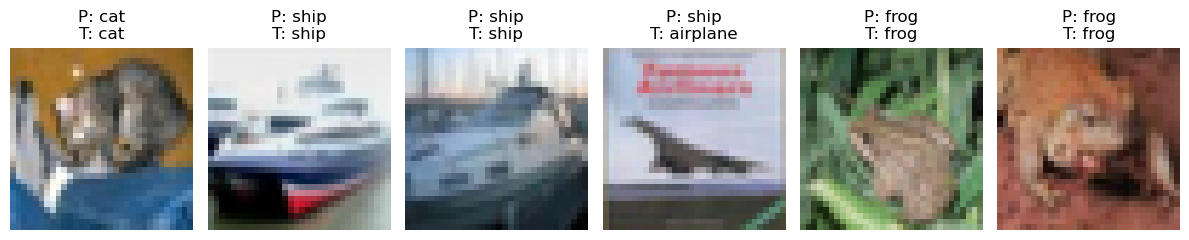

In [24]:
## Answer here

# Grab one test batch and predict.
images, labels = next(iter(test_loader))
model.eval()
with torch.no_grad():
    preds = model(images.to(device)).argmax(dim=1).cpu()

# Show the first 6 images with predicted (P) vs. true (T) labels.
mean = torch.tensor(cifar_mean).view(3, 1, 1)
std = torch.tensor(cifar_std).view(3, 1, 1)

plt.figure(figsize=(12, 4))
for i in range(6):
    img = (images[i] * std + mean).clamp(0, 1)   # un-normalize for display
    plt.subplot(1, 6, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"P: {classes[preds[i]]}\nT: {classes[labels[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()